In [4]:
#from src.database import get_connection, create_schemas, create_raw_tables, load_raw_data

In [5]:
%run ../src/database.py

# 1. Create connection
conn = get_connection()

# 2. Set up the database (schemas and tables) from scratch
create_schemas(conn)
create_raw_tables(conn)

# 3. Now load data from parquet files
load_raw_data(conn)

print("Database is ready and data has been loaded!")

Database is ready and data has been loaded!


In [6]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [7]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# Connecting to the database (setting read_only=True reduces the risk of 'File in use' errors)
conn = duckdb.connect('../data/weather_pipeline.duckdb', read_only=False)

# Fetching all raw data from the database table
df = conn.execute("SELECT * FROM raw.weather_daily").df()

# Converting the date column to the correct datetime format
df['date'] = pd.to_datetime(df['date'])

print(f"Total row count: {len(df)}")
df.head()

Total row count: 85


,city,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,data_type
0,Baki,2026-04-14,11.312499,2.305472,33141.066406,15.010000,79.314529,1021.701904,2.4,13.0,15.856354,79.000000,22.964998,0.283333,historical
1,Baki,2026-04-15,11.702085,3.136395,41735.414062,20.240000,69.572823,1024.161987,0.3,3.0,15.484185,47.250000,28.199997,0.277208,historical
2,Baki,2026-04-16,13.097917,3.106966,42755.191406,19.440001,65.637993,1023.956787,0.0,0.0,12.362475,20.416666,14.085001,0.260625,historical
3,Baki,2026-04-17,12.995834,3.021810,42742.210938,21.790001,80.436111,1024.379028,0.0,0.0,16.036171,22.750000,25.874998,0.239250,historical
4,Baki,2026-04-18,13.668750,2.861732,43815.843750,22.580000,83.649406,1016.915588,0.0,0.0,22.350464,27.541666,38.280003,0.212958,historical


In [8]:
df = conn.execute("SELECT * FROM read_parquet('../data/raw/*.parquet') ").df()
print(df.columns)

Index(['city', 'date', 'temperature_2m_mean', 'et0_fao_evapotranspiration_sum',
       'sunshine_duration', 'shortwave_radiation_sum',
       'relative_humidity_2m_mean', 'surface_pressure_mean',
       'precipitation_sum', 'precipitation_hours', 'wind_speed_10m_max',
       'cloud_cover_mean', 'wind_gusts_10m_mean',
       'soil_moisture_0_to_7cm_mean', 'data_type'],
      dtype='str')


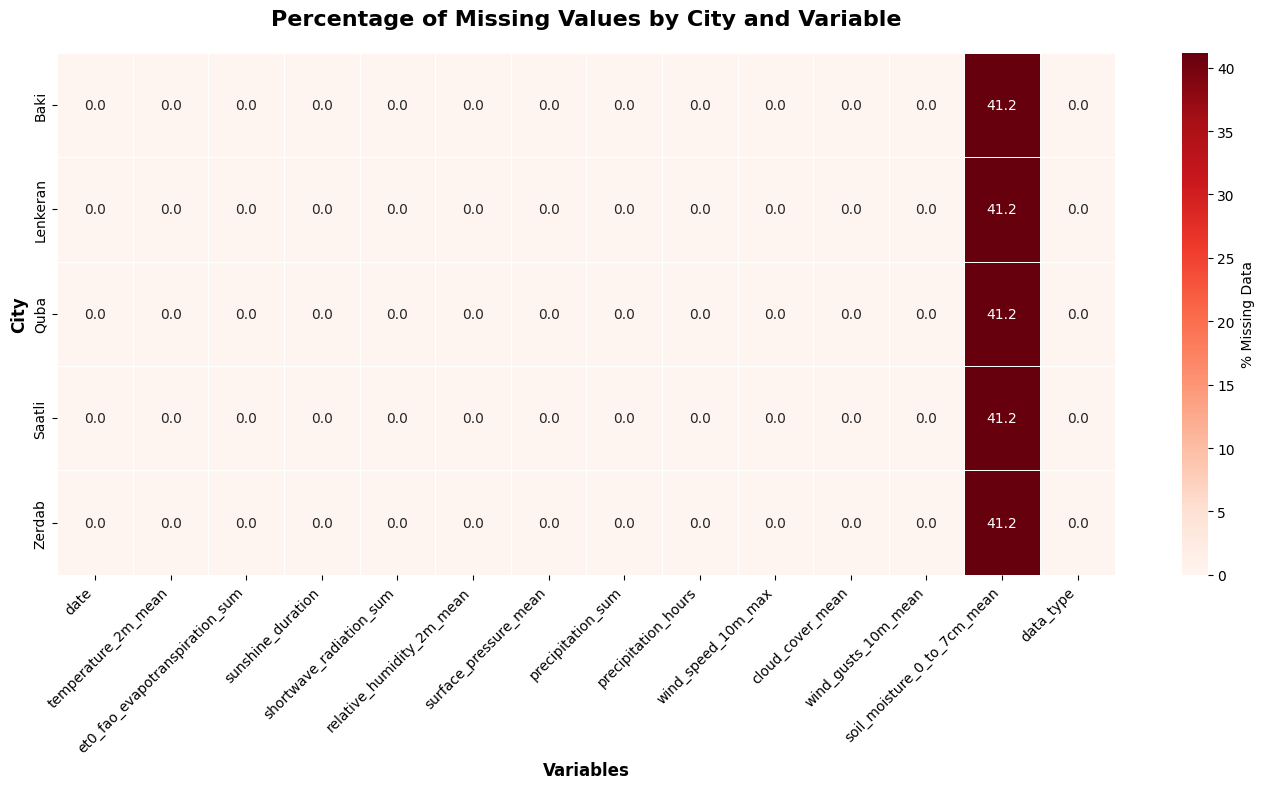

In [9]:
# 1. Create a DataFrame that is True for missing values and False for present values
missing_df = df.isna()

# 2. Add the 'city' column back so we can group by it
# (Note: If your column is named 'location' or something else, change 'city' to that name)
missing_df['city'] = df['city']

# 3. Calculate the percentage of missing values for each variable, grouped by city
missing_by_city = missing_df.groupby('city').mean() * 100

# 4. Visualize with a Seaborn Heatmap
plt.figure(figsize=(14, 8))

# annot=True adds the exact percentage numbers inside the boxes
# fmt=".1f" rounds the numbers to 1 decimal place
# cmap="Reds" makes the heatmap go from white (0%) to dark red (100%)
sns.heatmap(missing_by_city, 
            annot=True, 
            fmt=".1f", 
            cmap="Reds", 
            cbar_kws={'label': '% Missing Data'},
            linewidths=0.5)

plt.title("Percentage of Missing Values by City and Variable", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("City", fontsize=12, fontweight='bold')
plt.xlabel("Variables", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right') # Rotate x labels so they don't overlap
plt.tight_layout()
plt.show()

temperature_2m_mean → 7 outliers


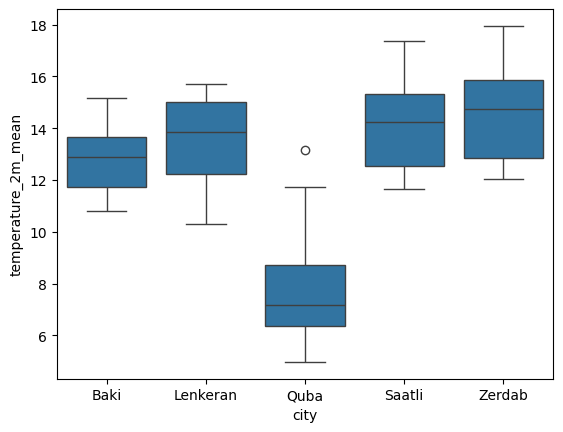

et0_fao_evapotranspiration_sum → 0 outliers


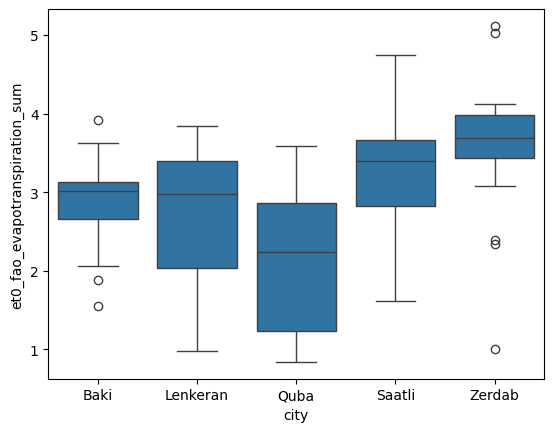

sunshine_duration → 0 outliers


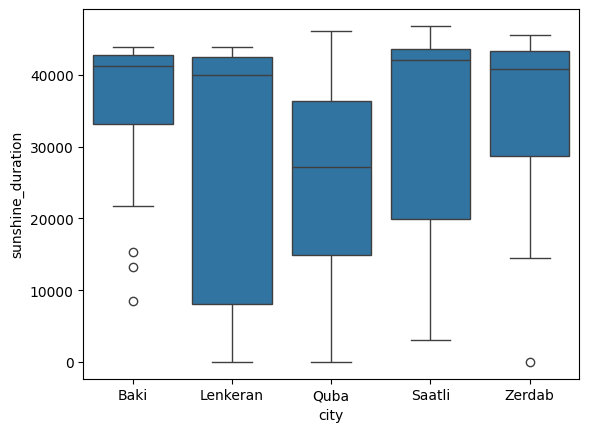

shortwave_radiation_sum → 0 outliers


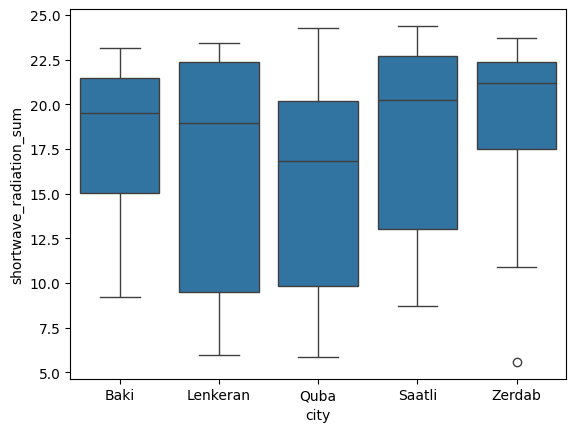

relative_humidity_2m_mean → 1 outliers


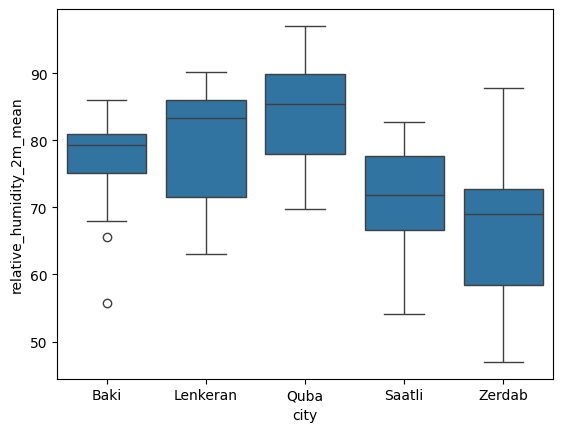

surface_pressure_mean → 17 outliers


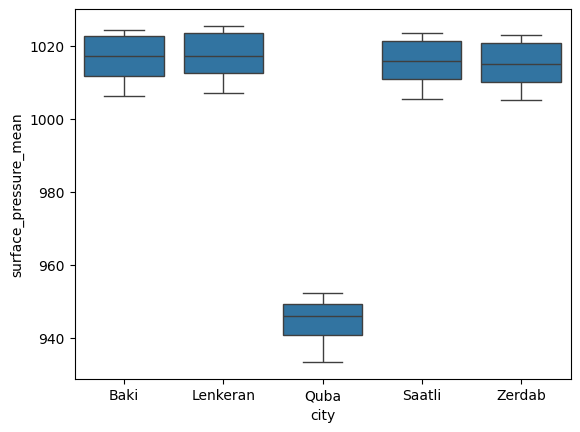

precipitation_sum → 13 outliers


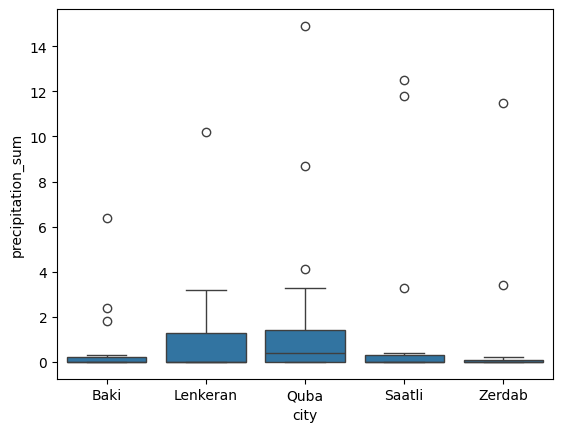

precipitation_hours → 10 outliers


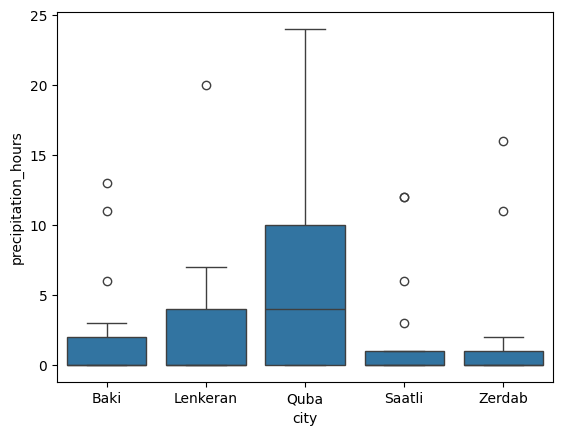

wind_speed_10m_max → 4 outliers


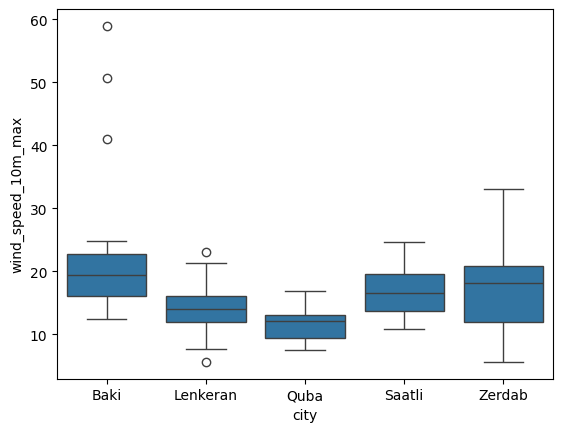

cloud_cover_mean → 0 outliers


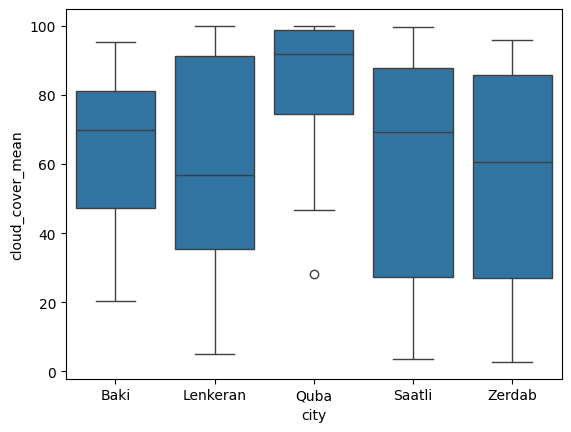

wind_gusts_10m_mean → 8 outliers


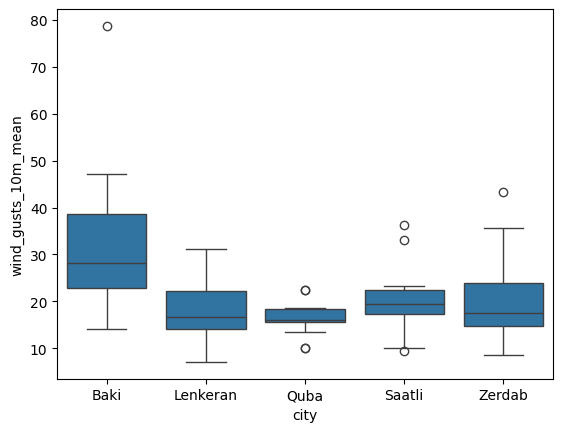

soil_moisture_0_to_7cm_mean → 0 outliers


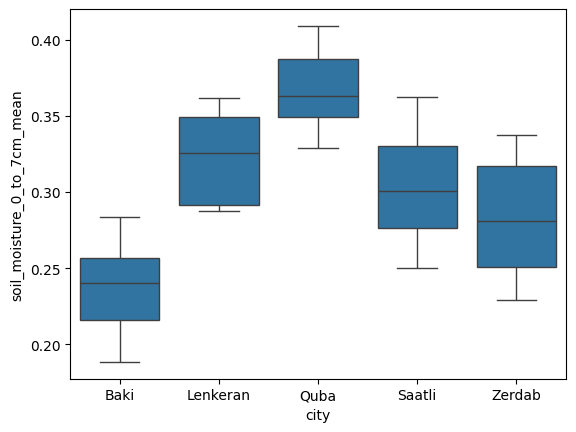

In [10]:
numeric_cols = df.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, "→", outliers, "outliers")
    sns.boxplot(x="city", y=col, data=df)
    plt.show()


In [11]:
(df.groupby("city")
   .apply(lambda x: x['date'].diff().dt.days.value_counts())
)


date,1.0
city,
Baki,16
Lenkeran,16
Quba,16
Saatli,16
Zerdab,16


In [12]:
pd.date_range(df['date'].min(), df['date'].max()).difference(df['date'])


DatetimeIndex([], dtype='datetime64[us, Asia/Baku]', freq='D')

In [13]:
cutoff_date = df['date'].max() - pd.Timedelta(days=6)  # son 7 gün forecast-dır
hist_df = df[df['date'] < cutoff_date]
forecast_df = df[df['date'] >= cutoff_date]


In [14]:
common_dates = df.groupby('city')['date'].apply(lambda x: x.duplicated().sum())
print(common_dates)


city
Baki        0
Lenkeran    0
Quba        0
Saatli      0
Zerdab      0
Name: date, dtype: int64


In [15]:
for col in numeric_cols:
    df['dup_count'] = (df[col] == df[col].shift()).astype(int)
    if df['dup_count'].rolling(5).sum().max() > 4:
        print(col, "→ more sequence")


precipitation_sum → more sequence
precipitation_hours → more sequence


In [16]:
df['precipitation_sum']

0     2.4
1     0.3
2     0.0
3     0.0
4     0.0
     ... 
80    0.0
81    0.0
82    0.0
83    0.0
84    0.0
Name: precipitation_sum, Length: 85, dtype: float32

In [17]:
%run ../src/cleaning.py

In [18]:
cleaned_df = clean_raw_to_staging(conn)
cleaned_df.head(10)


🔄 Cleaning data from raw.weather_daily ...
📥 Raw data loaded: 85 rows, 15 columns

📅 Date continuity summary:
       city start_date   end_date  expected_days  actual_days  missing_days  \
0      Baki 2026-04-14 2026-04-30             17           17             0   
1  Lenkeran 2026-04-14 2026-04-30             17           17             0   
2      Quba 2026-04-14 2026-04-30             17           17             0   
3    Saatli 2026-04-14 2026-04-30             17           17             0   
4    Zerdab 2026-04-14 2026-04-30             17           17             0   

  missing_list  
0           []  
1           []  
2           []  
3           []  
4           []  

✅ Cleaned data written to staging.weather_daily
📊 Sample of cleaned data:
city       date  temperature_2m_mean  et0_fao_evapotranspiration_sum  sunshine_duration  shortwave_radiation_sum  relative_humidity_2m_mean  surface_pressure_mean  precipitation_sum  precipitation_hours  wind_speed_10m_max  cloud_cover_me

,city,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,data_type
0,Baki,2026-04-14,11.312499,2.305472,33141.066406,15.010000,79.314529,1021.701904,2.4,13.0,15.856354,79.000000,22.964998,0.283333,historical
1,Baki,2026-04-15,11.702085,3.136395,41735.414062,20.240000,69.572823,1024.161987,0.3,3.0,15.484185,47.250000,28.199997,0.277208,historical
2,Baki,2026-04-16,13.097917,3.106966,42755.191406,19.440001,65.637993,1023.956787,0.0,0.0,12.362475,20.416666,14.085001,0.260625,historical
3,Baki,2026-04-17,12.995834,3.021810,42742.210938,21.790001,80.436111,1024.379028,0.0,0.0,16.036171,22.750000,25.874998,0.239250,historical
4,Baki,2026-04-18,13.668750,2.861732,43815.843750,22.580000,83.649406,1016.915588,0.0,0.0,22.350464,27.541666,38.280003,0.212958,historical
5,Baki,2026-04-19,15.177083,3.267373,41231.125000,21.450001,80.289223,1006.191345,0.1,1.0,20.803045,51.625000,34.079998,0.188708,historical
6,Baki,2026-04-20,13.847917,2.064010,8520.239258,9.200000,76.577911,1011.642517,1.8,6.0,24.725605,95.208336,47.235001,0.188417,historical
7,Baki,2026-04-21,10.787499,1.553613,13218.458984,9.220000,83.323708,1015.477234,6.4,11.0,22.158285,75.750000,38.565002,0.244083,historical
8,Baki,2026-04-22,13.112499,3.127617,43021.062500,20.930000,80.909668,1013.233398,0.0,0.0,18.501513,51.833332,25.094997,0.240625,historical
9,Baki,2026-04-23,12.887501,1.882021,21648.394531,13.040000,86.022186,1011.448242,0.1,1.0,19.380743,58.000000,29.189997,0.225250,historical


In [19]:
# 1. Run the pipeline to clean and save the data to DuckDB
clean_raw_to_staging(conn)

# 2. Fetch the newly saved staging data from the database
cleaned_df = conn.execute("SELECT * FROM staging.weather_daily").df()

# 3. View the first 10 rows
cleaned_df.head(10)

🔄 Cleaning data from raw.weather_daily ...
📥 Raw data loaded: 85 rows, 15 columns

📅 Date continuity summary:
       city start_date   end_date  expected_days  actual_days  missing_days  \
0      Baki 2026-04-14 2026-04-30             17           17             0   
1  Lenkeran 2026-04-14 2026-04-30             17           17             0   
2      Quba 2026-04-14 2026-04-30             17           17             0   
3    Saatli 2026-04-14 2026-04-30             17           17             0   
4    Zerdab 2026-04-14 2026-04-30             17           17             0   

  missing_list  
0           []  
1           []  
2           []  
3           []  
4           []  

✅ Cleaned data written to staging.weather_daily
📊 Sample of cleaned data:
city       date  temperature_2m_mean  et0_fao_evapotranspiration_sum  sunshine_duration  shortwave_radiation_sum  relative_humidity_2m_mean  surface_pressure_mean  precipitation_sum  precipitation_hours  wind_speed_10m_max  cloud_cover_me

,city,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,data_type
0,Baki,2026-04-14,11.312499,2.305472,33141.066406,15.010000,79.314529,1021.701904,2.4,13.0,15.856354,79.000000,22.964998,0.283333,historical
1,Baki,2026-04-15,11.702085,3.136395,41735.414062,20.240000,69.572823,1024.161987,0.3,3.0,15.484185,47.250000,28.199997,0.277208,historical
2,Baki,2026-04-16,13.097917,3.106966,42755.191406,19.440001,65.637993,1023.956787,0.0,0.0,12.362475,20.416666,14.085001,0.260625,historical
3,Baki,2026-04-17,12.995834,3.021810,42742.210938,21.790001,80.436111,1024.379028,0.0,0.0,16.036171,22.750000,25.874998,0.239250,historical
4,Baki,2026-04-18,13.668750,2.861732,43815.843750,22.580000,83.649406,1016.915588,0.0,0.0,22.350464,27.541666,38.280003,0.212958,historical
5,Baki,2026-04-19,15.177083,3.267373,41231.125000,21.450001,80.289223,1006.191345,0.1,1.0,20.803045,51.625000,34.079998,0.188708,historical
6,Baki,2026-04-20,13.847917,2.064010,8520.239258,9.200000,76.577911,1011.642517,1.8,6.0,24.725605,95.208336,47.235001,0.188417,historical
7,Baki,2026-04-21,10.787499,1.553613,13218.458984,9.220000,83.323708,1015.477234,6.4,11.0,22.158285,75.750000,38.565002,0.244083,historical
8,Baki,2026-04-22,13.112499,3.127617,43021.062500,20.930000,80.909668,1013.233398,0.0,0.0,18.501513,51.833332,25.094997,0.240625,historical
9,Baki,2026-04-23,12.887501,1.882021,21648.394531,13.040000,86.022186,1011.448242,0.1,1.0,19.380743,58.000000,29.189997,0.225250,historical


In [20]:
cleaned_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   city                            85 non-null     str           
 1   date                            85 non-null     datetime64[us]
 2   temperature_2m_mean             85 non-null     float64       
 3   et0_fao_evapotranspiration_sum  85 non-null     float64       
 4   sunshine_duration               85 non-null     float64       
 5   shortwave_radiation_sum         85 non-null     float64       
 6   relative_humidity_2m_mean       85 non-null     float64       
 7   surface_pressure_mean           85 non-null     float64       
 8   precipitation_sum               85 non-null     float64       
 9   precipitation_hours             85 non-null     float64       
 10  wind_speed_10m_max              85 non-null     float64       
 11  cloud_cover_mean   

In [21]:
%run ../src/features.py
created_features_df=create_features(conn)
created_features_df.head()

🔧 Generating features from staging.weather_daily ...
✅ Features computed: day_of_year, precip_sum_7d, prev_soil_moisture

Data now has 85 rows and 18 columns.

📊 Example of engineered data:
city       date  temperature_2m_mean  et0_fao_evapotranspiration_sum  sunshine_duration  shortwave_radiation_sum  relative_humidity_2m_mean  surface_pressure_mean  precipitation_sum  precipitation_hours  wind_speed_10m_max  cloud_cover_mean  wind_gusts_10m_mean  soil_moisture_0_to_7cm_mean  data_type  day_of_year  precip_sum_7d  prev_soil_moisture
Baki 2026-04-14            11.312499                        2.305472       33141.066406                15.010000                  79.314529            1021.701904                2.4                 13.0           15.856354         79.000000            22.964998                     0.283333 historical          104            2.4                 NaN
Baki 2026-04-15            11.702085                        3.136395       41735.414062                20.2400

,city,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,data_type,day_of_year,precip_sum_7d,prev_soil_moisture
0,Baki,2026-04-14,11.312499,2.305472,33141.066406,15.010000,79.314529,1021.701904,2.4,13.0,15.856354,79.000000,22.964998,0.283333,historical,104,2.4,NaN
1,Baki,2026-04-15,11.702085,3.136395,41735.414062,20.240000,69.572823,1024.161987,0.3,3.0,15.484185,47.250000,28.199997,0.277208,historical,105,2.7,0.283333
2,Baki,2026-04-16,13.097917,3.106966,42755.191406,19.440001,65.637993,1023.956787,0.0,0.0,12.362475,20.416666,14.085001,0.260625,historical,106,2.7,0.277208
3,Baki,2026-04-17,12.995834,3.021810,42742.210938,21.790001,80.436111,1024.379028,0.0,0.0,16.036171,22.750000,25.874998,0.239250,historical,107,2.7,0.260625
4,Baki,2026-04-18,13.668750,2.861732,43815.843750,22.580000,83.649406,1016.915588,0.0,0.0,22.350464,27.541666,38.280003,0.212958,historical,108,2.7,0.239250


In [22]:
created_features_df[created_features_df['city']=='Baki']

,city,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,data_type,day_of_year,precip_sum_7d,prev_soil_moisture
0,Baki,2026-04-14,11.312499,2.305472,33141.066406,15.010000,79.314529,1021.701904,2.4,13.0,15.856354,79.000000,22.964998,0.283333,historical,104,2.4,NaN
1,Baki,2026-04-15,11.702085,3.136395,41735.414062,20.240000,69.572823,1024.161987,0.3,3.0,15.484185,47.250000,28.199997,0.277208,historical,105,2.7,0.283333
2,Baki,2026-04-16,13.097917,3.106966,42755.191406,19.440001,65.637993,1023.956787,0.0,0.0,12.362475,20.416666,14.085001,0.260625,historical,106,2.7,0.277208
3,Baki,2026-04-17,12.995834,3.021810,42742.210938,21.790001,80.436111,1024.379028,0.0,0.0,16.036171,22.750000,25.874998,0.239250,historical,107,2.7,0.260625
4,Baki,2026-04-18,13.668750,2.861732,43815.843750,22.580000,83.649406,1016.915588,0.0,0.0,22.350464,27.541666,38.280003,0.212958,historical,108,2.7,0.239250
5,Baki,2026-04-19,15.177083,3.267373,41231.125000,21.450001,80.289223,1006.191345,0.1,1.0,20.803045,51.625000,34.079998,0.188708,historical,109,2.8,0.212958
6,Baki,2026-04-20,13.847917,2.064010,8520.239258,9.200000,76.577911,1011.642517,1.8,6.0,24.725605,95.208336,47.235001,0.188417,historical,110,4.6,0.188708
7,Baki,2026-04-21,10.787499,1.553613,13218.458984,9.220000,83.323708,1015.477234,6.4,11.0,22.158285,75.750000,38.565002,0.244083,historical,111,8.6,0.188417
8,Baki,2026-04-22,13.112499,3.127617,43021.062500,20.930000,80.909668,1013.233398,0.0,0.0,18.501513,51.833332,25.094997,0.240625,historical,112,8.3,0.244083
9,Baki,2026-04-23,12.887501,1.882021,21648.394531,13.040000,86.022186,1011.448242,0.1,1.0,19.380743,58.000000,29.189997,0.225250,historical,113,8.4,0.240625


In [23]:
created_features_df

,city,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,data_type,day_of_year,precip_sum_7d,prev_soil_moisture
0,Baki,2026-04-14,11.312499,2.305472,33141.066406,15.010000,79.314529,1021.701904,2.4,13.0,15.856354,79.000000,22.964998,0.283333,historical,104,2.4,NaN
1,Baki,2026-04-15,11.702085,3.136395,41735.414062,20.240000,69.572823,1024.161987,0.3,3.0,15.484185,47.250000,28.199997,0.277208,historical,105,2.7,0.283333
2,Baki,2026-04-16,13.097917,3.106966,42755.191406,19.440001,65.637993,1023.956787,0.0,0.0,12.362475,20.416666,14.085001,0.260625,historical,106,2.7,0.277208
3,Baki,2026-04-17,12.995834,3.021810,42742.210938,21.790001,80.436111,1024.379028,0.0,0.0,16.036171,22.750000,25.874998,0.239250,historical,107,2.7,0.260625
4,Baki,2026-04-18,13.668750,2.861732,43815.843750,22.580000,83.649406,1016.915588,0.0,0.0,22.350464,27.541666,38.280003,0.212958,historical,108,2.7,0.239250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Zerdab,2026-04-26,14.039833,3.082464,29227.609375,17.500000,68.958336,1020.760742,0.0,0.0,19.576189,85.791664,17.445000,NaN,forecast,116,15.0,NaN
81,Zerdab,2026-04-27,17.952332,5.028692,45515.457031,23.530001,60.458332,1010.165833,0.0,0.0,24.633049,83.708336,23.984999,NaN,forecast,117,11.6,NaN
82,Zerdab,2026-04-28,15.491916,3.685580,16628.697266,10.940000,50.041668,1019.290955,0.0,0.0,26.980793,88.125000,35.595001,NaN,forecast,118,0.1,NaN
83,Zerdab,2026-04-29,12.838752,2.393121,16414.091797,13.720000,56.489582,1022.086243,0.0,0.0,6.193674,90.375000,8.827499,NaN,forecast,119,0.1,NaN


In [24]:
conn.close()